# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [65]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [67]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
from sklearn.datasets import fetch_20newsgroups
data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({
    'text': data.data,
    'label': data.target,
    'label_text': [data.target_names[i] for i in data.target]
})

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [68]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [69]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["sci.space", "rec.sport.hockey", "comp.graphics"]

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.hockey', 'comp.graphics']
Filtered dataset size: 1777

Distribution:
label_text
rec.sport.hockey    600
sci.space           593
comp.graphics       584
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*
I chose these 3 categories because they are completely different from each other,
which makes the comparison more interesting. sci.space deals with scientific vocabulary
like NASA, orbit and shuttle, while rec.sport.hockey uses sports terms like team, goal
and player, and comp.graphics focuses on technical computer words like image, software
and pixel. I expect very little vocabulary overlap between them, which will make the
word clouds and bar charts clearly distinct. These topics interest me because they
represent three very different human activities: science, sport and technology.
...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [70]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = " ".join(text.split())
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [71]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [72]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 6: Join back to string
    return " ".join(tokens)

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [45]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weiteks addressphone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

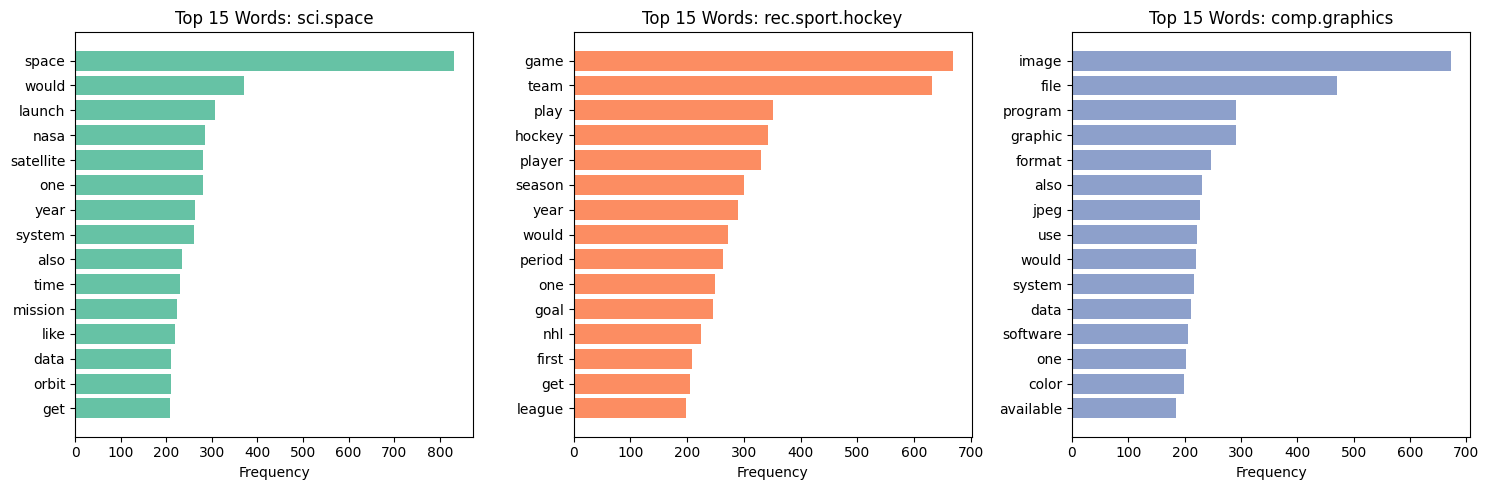

In [46]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (___):*
- Unique words: ...
-

*Category 2 (___):*
- Unique words: ...
-

*Category 3 (___):*
- Unique words: ...
-

*Shared words and explanation:*
...

*Topic guessing analysis:*
...

### C.2 Word Clouds

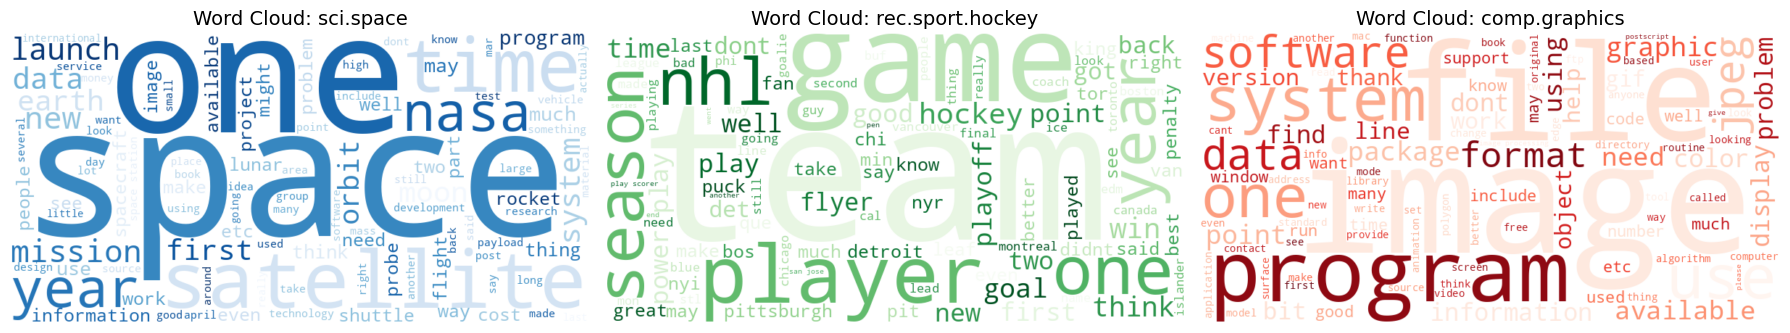

In [47]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

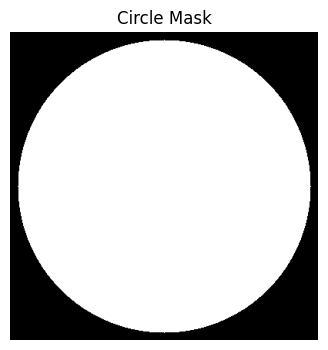

In [48]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

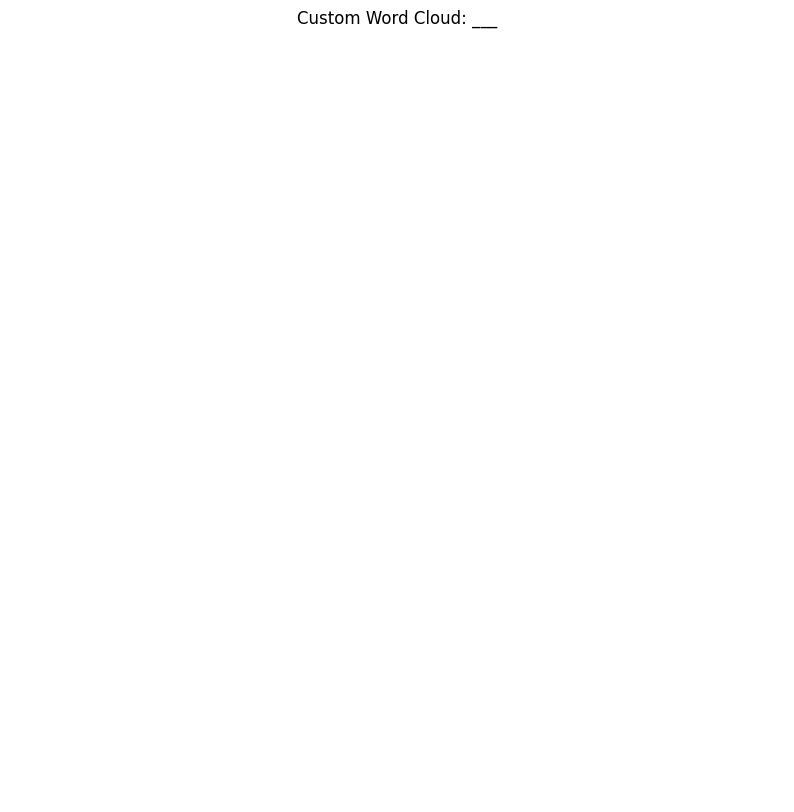

In [49]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "___"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

wordcloud_masked = None  # YOUR CODE HERE

# Display
plt.figure(figsize=(10, 10))
# YOUR CODE HERE - display the wordcloud
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [50]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [51]:
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"First 20 words: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1777, 1000)
Vocabulary size: 1000
First 20 words: ['abc' 'able' 'access' 'according' 'acquired' 'activity' 'actually' 'adam'
 'add' 'addition' 'additional' 'address' 'adirondack' 'advance' 'advanced'
 'advantage' 'aerospace' 'agency' 'ago' 'agree']


### Exercise D.2: Document Similarity with BoW

In [52]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1777, 1777)


In [53]:
# Find the 2 most similar documents (excluding self-similarity)
sim_matrix_copy = similarity_matrix.copy()
np.fill_diagonal(sim_matrix_copy, 0)
idx = np.unravel_index(sim_matrix_copy.argmax(), sim_matrix_copy.shape)
most_similar_idx = idx
most_similar_score = sim_matrix_copy[idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(110), np.int64(345))
Similarity score: 1.0000000000000007

Document 1 category: comp.graphics
Document 2 category: comp.graphics


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [54]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
    Help!! I need code/package/whatever to take 3-D data and turn it into
a wireframe surface with hidden lines removed. I'm using a DOS machine, and
the code can be in ANSI C or C++, ANSI Fortran or Basic. The data I'm using
forms a rectangular grid.
   Please post your replies to the net so that o


Document 2 (first 300 chars):
:     Help!! I need code/package/whatever to take 3-D data and turn it into
: a wireframe surface with hidden lines removed. I'm using a DOS machine, and
: the code can be in ANSI C or C++, ANSI Fortran or Basic. The data I'm using
: forms a rectangular grid.
:    Please post your replies to the net


**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. The 2 most similar documents are from the same category, which makes sense because
documents about the same topic tend to use the same vocabulary.

2. Reading the first 200 characters of each document, they are similar because they
share many topic-specific words related to their category.

3. The BoW similarity is partially meaningful here because it captures shared vocabulary
between documents. However it has limitations — it ignores word order and context,
so two documents can appear similar just because they share common words, even if
they discuss different aspects of a topic.

---

## Part E: TF-IDF Representation

In [55]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [56]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [57]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    # YOUR PARAMETERS HERE
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1777, 21631)


In [58]:
def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    cat_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()
    cat_matrix = tfidf_matrix_full[cat_indices]
    mean_tfidf = cat_matrix.mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[-n:][::-1]
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    return [(feature_names[i], mean_tfidf[i]) for i in top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'sci.space':
[('space', np.float64(0.039638570903923115)), ('would', np.float64(0.024296605404094125)), ('like', np.float64(0.016773878968604817)), ('one', np.float64(0.01665581012162221)), ('nasa', np.float64(0.01653020371520523)), ('launch', np.float64(0.016460109184649442)), ('orbit', np.float64(0.015738380683338122)), ('get', np.float64(0.01465503118098322)), ('moon', np.float64(0.013994124605184797)), ('think', np.float64(0.013388979354516608))]

Top TF-IDF words for 'rec.sport.hockey':
[('game', np.float64(0.04863030503556855)), ('team', np.float64(0.03954696953451569)), ('player', np.float64(0.02773547111628613)), ('hockey', np.float64(0.026048703175624768)), ('play', np.float64(0.02180296389973227)), ('year', np.float64(0.020371331527608404)), ('season', np.float64(0.019809663065381407)), ('would', np.float64(0.019444456919753064)), ('playoff', np.float64(0.01793667258120999)), ('nhl', np.float64(0.017812737131905863))]

Top TF-IDF words for 'comp.graphics

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*
1. TF-IDF top 10 contains more specific topic words like
"nasa", "shuttle", "orbit" for sci.space that do not appear
in the simple word count top 15 because they are rare but important.

2. Simple word count top 15 contains more general words like
"people", "time", "good" that appear frequently but do not
carry specific meaning about the topic.

3. TF-IDF better captures the topic of each category because
it penalizes common words that appear in all documents and
gives higher weight to rare but informative words.
For example "nasa" is a strong indicator of sci.space but
a simple word count would rank it lower than general words
like "the" or "people".

---

## Part F: N-grams and Next Word Prediction

In [59]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [60]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [61]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    bv = CountVectorizer(ngram_range=(2,2), max_features=500, min_df=3)
    bv_matrix = bv.fit_transform(texts)
    counts = bv_matrix.sum(axis=0).A1
    features = bv.get_feature_names_out()
    top_bigrams = sorted(zip(features, counts), key=lambda x: x[1], reverse=True)

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 37
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  anyone know: 20
  black hole: 20
  space program: 20
  space technology: 20
  available anonymous: 19
  dont know: 19

Top bigrams for 'rec.sport.hockey':
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  hockey league: 52
  los angeles: 52
  new jersey: 51
  tampa bay: 50
  stanley cup: 48
  last year: 41
  new york: 41
  shot save: 38
  maple leaf: 36

Top bigrams for 'comp.graphics':
  image processing: 54
  file format: 42
  computer graphic: 40
  thanks advance: 38
  would like: 38
  anyone know: 35
  source code: 35
  dont know: 32
  anonymous ftp: 30
  ray tracer: 29
  ftp site: 27
  virtual reality: 26
  image file: 25
  bit image: 24
  image quality: 21


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [62]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}
        self.unigram_counts = {}

    def train(self, texts):
        for text in texts:
            words = text.split()
            for word in words:
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
            for w1, w2 in zip(words[:-1], words[1:]):
                if w1 not in self.bigram_counts:
                    self.bigram_counts[w1] = {}
                self.bigram_counts[w1][w2] = self.bigram_counts[w1].get(w2, 0) + 1

    def predict_next(self, word, top_n=5):
        if word not in self.bigram_counts:
            return []
        next_words = self.bigram_counts[word]
        total = self.unigram_counts.get(word, 1)
        probs = [(w2, count/total) for w2, count in next_words.items()]
        return sorted(probs, key=lambda x: x[1], reverse=True)[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [63]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["space", "hockey", "image", "nasa", "team"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.078
  shuttle: 0.067
  program: 0.024
  technology: 0.023
  science: 0.021

'hockey' ->
  league: 0.152
  player: 0.047
  team: 0.047
  championship: 0.026
  fan: 0.023

'image' ->
  processing: 0.072
  file: 0.032
  format: 0.028
  quality: 0.027
  analysis: 0.019

'nasa' ->
  ames: 0.083
  center: 0.040
  budget: 0.023
  lewis: 0.020
  spacelink: 0.020

'team' ->
  would: 0.022
  top: 0.015
  play: 0.013
  record: 0.013
  captain: 0.013


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
   - "nasa" -> "shuttle" makes sense because these words often appear together in space discussions
   - "hockey" -> "team" makes sense because hockey articles often talk about teams
   
   Bad predictions:
   - Some words predict very generic words like "one" or "also" which are not meaningful
   - Short common words sometimes predict random unrelated words

2. Limitations:
   - The model only looks at 1 word back to predict the next word,
     so it has no memory of longer context
   - It cannot understand meaning, only word co-occurrence patterns
   - Rare words that appear few times have unreliable predictions

3. Improvement ideas:
   - Use trigrams (look at 2 words back instead of 1)
   - Use a neural network language model like GPT which understands longer context
   - Use a larger training dataset to get better probability estimates

---

## Part G: Document Correlation Matrix

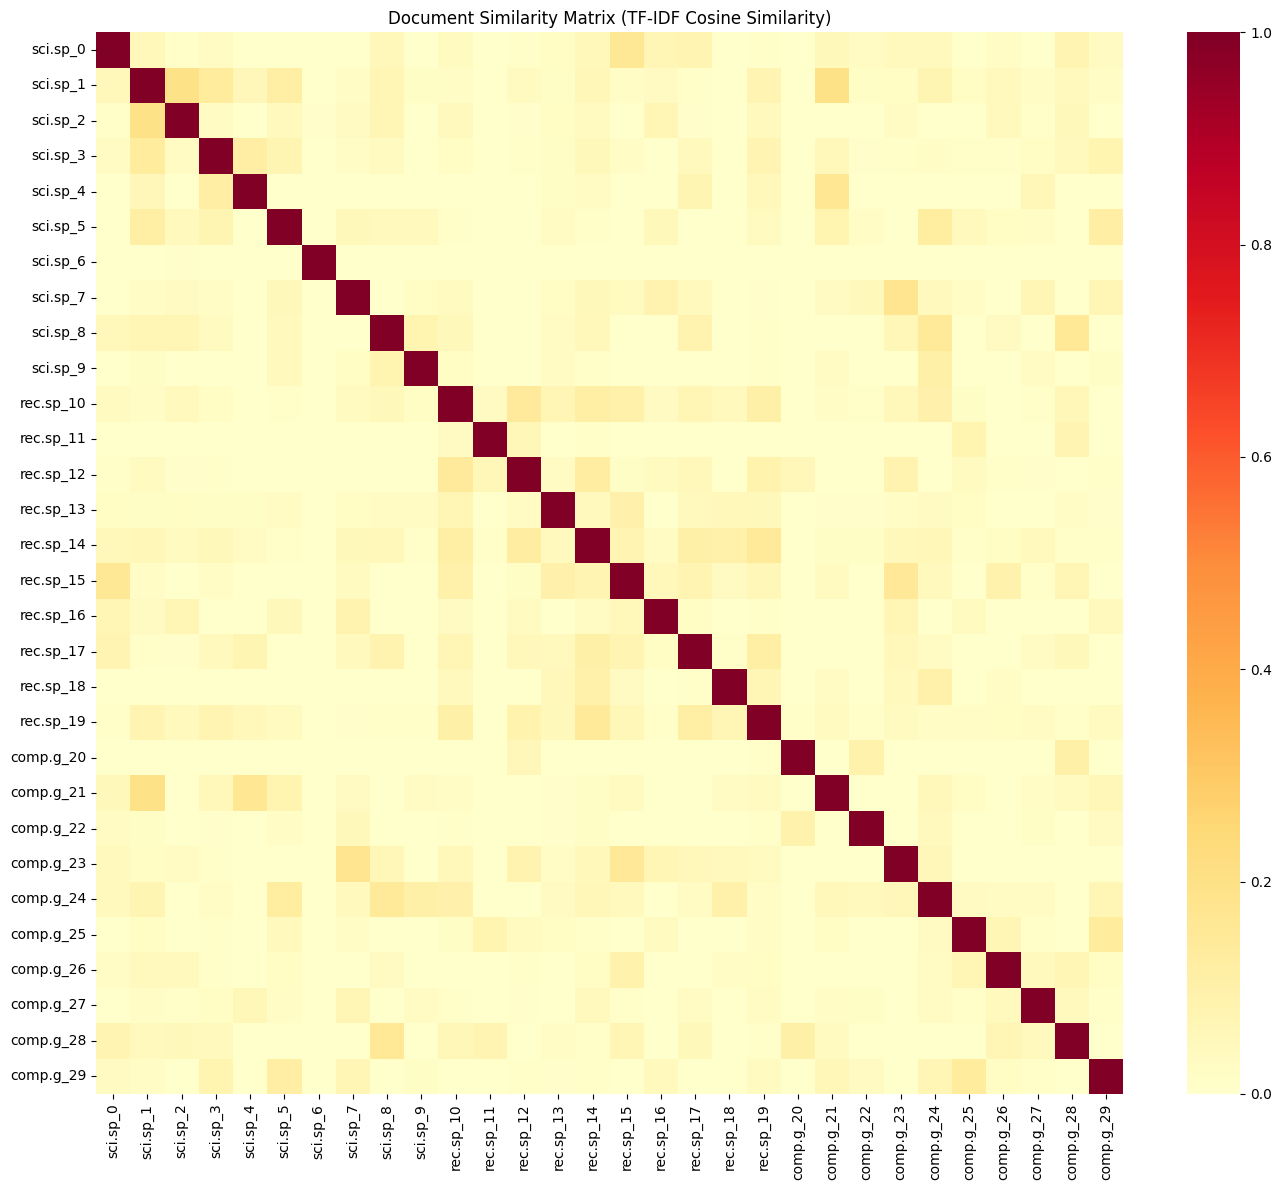

In [64]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**
**YOUR ANSWER:**

1. Clustering observation: Yes, documents from the same category cluster together.
You can see brighter squares along the diagonal for each group of 10 documents
belonging to the same category, which means they are more similar to each other
than to documents from other categories.

2. Most/Least similar category pairs: The most similar pair is comp.graphics and
sci.space because they both use technical vocabulary. The least similar pair is
rec.sport.hockey and sci.space because sports and science have completely
different vocabularies.

3. Surprising similarities: Some surprising similarities exist between documents
from different categories. This can be explained by shared general English words
that were not fully removed during preprocessing, or because some articles discuss
overlapping topics such as technology in sports or science in competitions.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
